# Bank Customer Churn Prediction

In [187]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('/content/Churn_Modelling.csv')
display(df.head())

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [277]:
df.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BalanceSalaryRatio,ProductsPerTenure
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700,3.790150,0.367173
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769,100.055758,0.337760
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,0.090909
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,0.166667
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.746998,0.250000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,1.514002,0.500000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,9770.883148,3.000000


In [188]:
df.info()
print(df.isnull().sum()) # null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography 

### Data Cleaning & Feature Engineering
Removing identifiers that don't contribute and create new features to capture complex relationships.

In [189]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [190]:
df.shape

(10000, 14)

In [191]:
df.duplicated().sum() # no duplicate

np.int64(0)

<Axes: xlabel='Exited'>

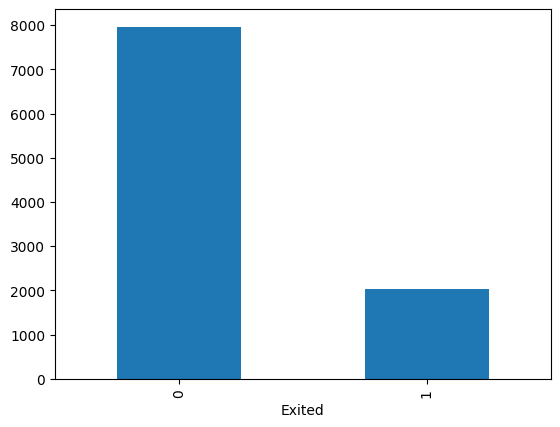

In [192]:
df['Exited'].value_counts().plot(kind='bar')

### Exploratory Data Analysis (EDA)
Identify patterns between customer features and their churn status ('Exited').

**Note:** The dataset is imbalanced (80/20 split).

In [193]:
num_cols = [
    'CreditScore',
    'Age',
    'Balance',
    'EstimatedSalary',
    'Tenure'
]

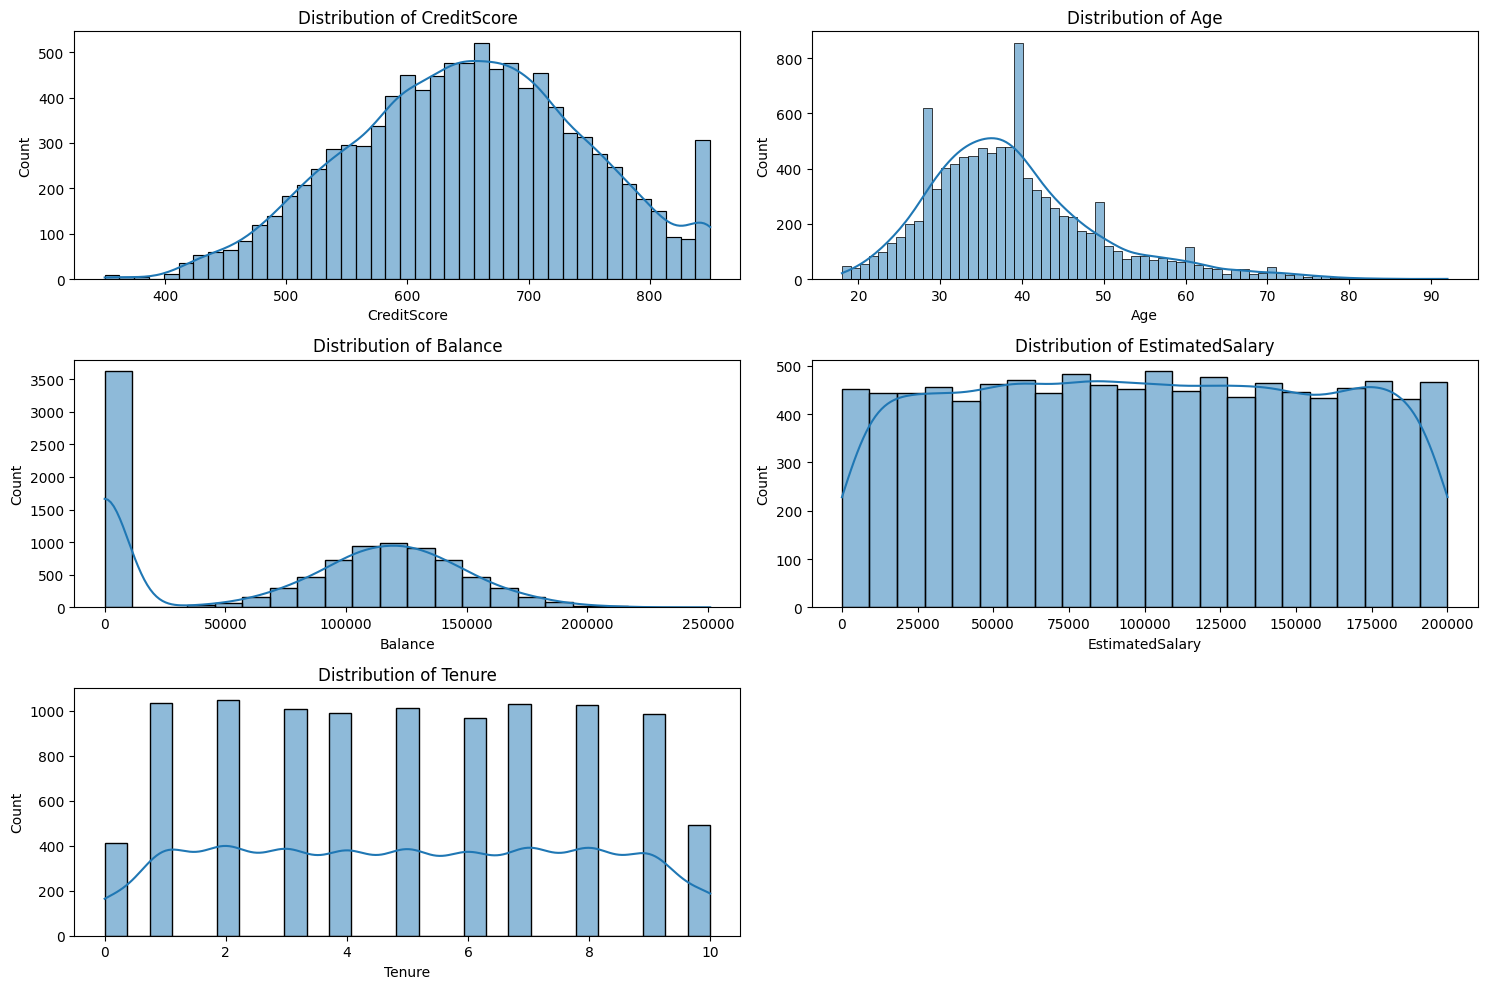

In [194]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 2, i)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

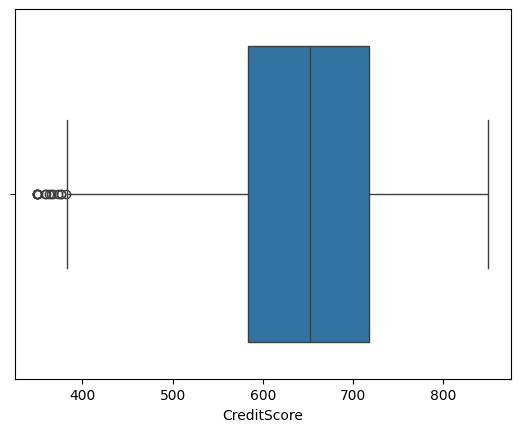

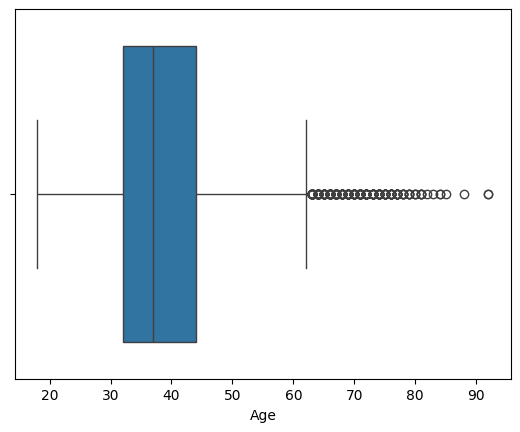

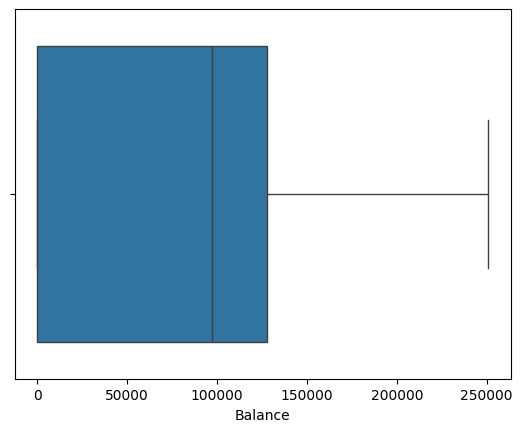

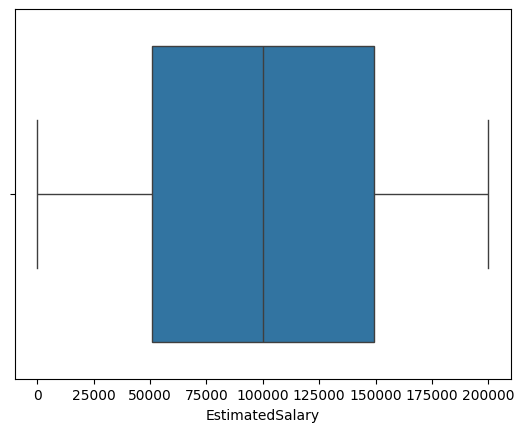

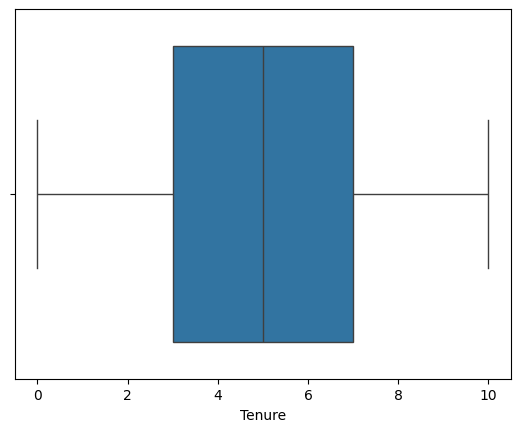

In [195]:
for col in num_cols:
    sns.boxplot(x=df[col])
    plt.show()

,proportion
Geography,
France,50.14
Germany,25.09
Spain,24.77


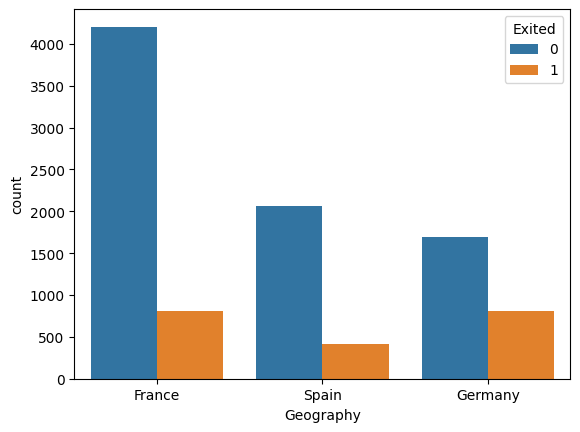

In [284]:
sns.countplot(x=df['Geography'],hue=df['Exited'])
df['Geography'].value_counts(normalize=True)*100


,proportion
Gender,
Male,54.57
Female,45.43


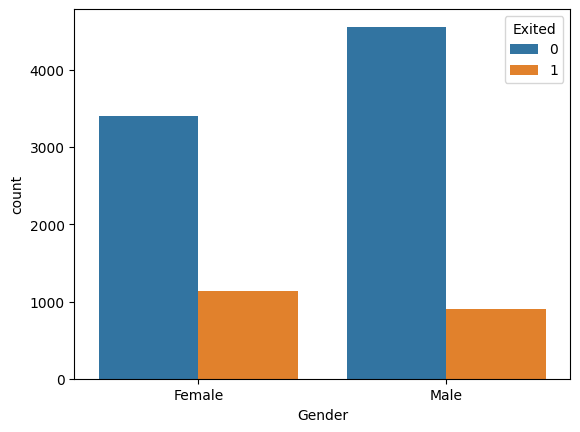

In [197]:
sns.countplot(x=df['Gender'],hue=df['Exited'])
df['Gender'].value_counts(normalize=True)*100

,proportion
Age,
37,4.78
38,4.77
35,4.74
36,4.56
34,4.47
...,...
84,0.02
82,0.01
88,0.01


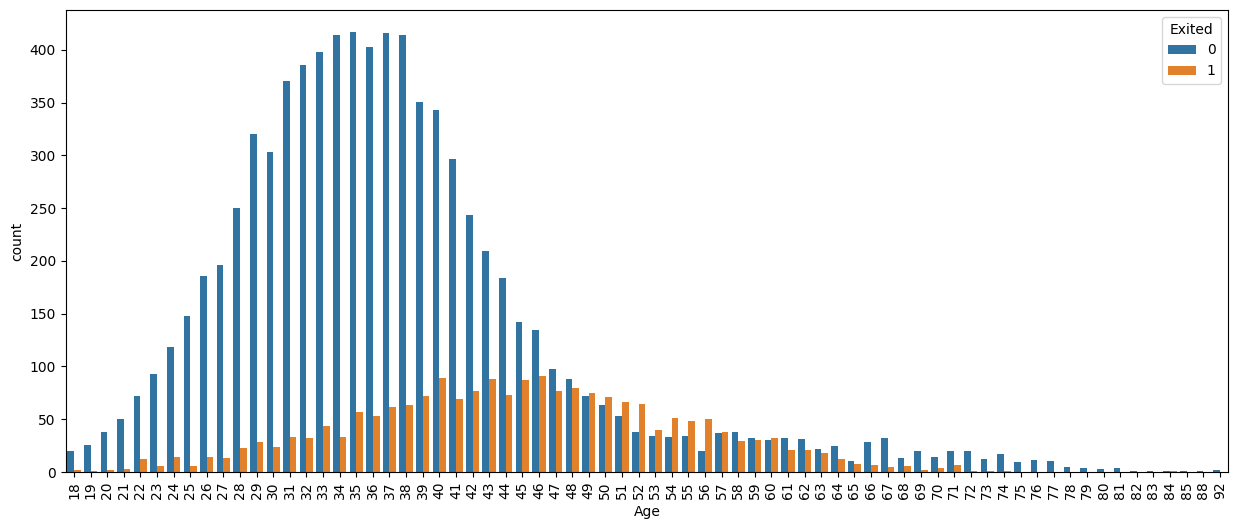

In [289]:
plt.figure(figsize=(15, 6))
sns.countplot(x=df['Age'], hue=df['Exited'])
plt.xticks(rotation=90)

display(df['Age'].value_counts(normalize=True)*100)

<Axes: xlabel='Exited', ylabel='Age'>

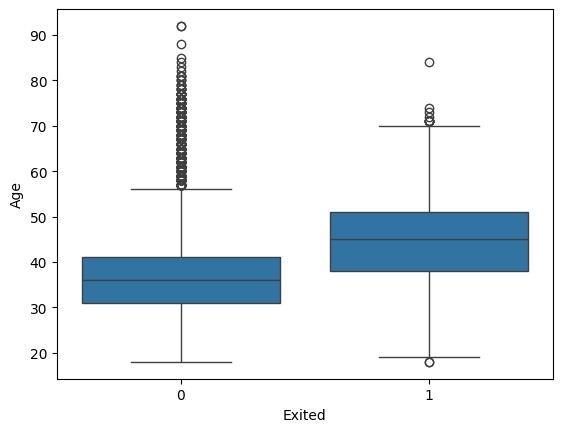

In [198]:
sns.boxplot(
    x='Exited',
    y='Age',
    data=df
)

<Axes: xlabel='Exited', ylabel='Balance'>

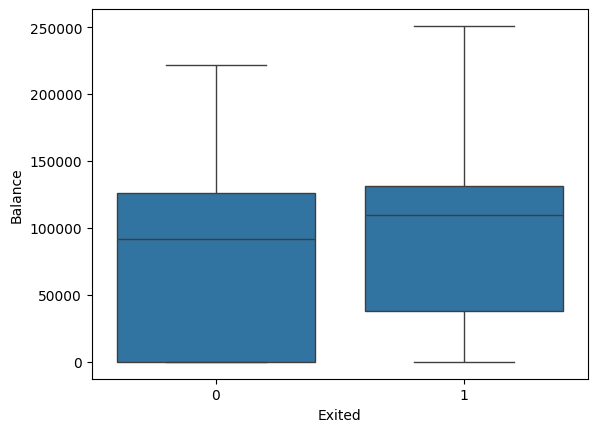

In [199]:
sns.boxplot(x='Exited', y='Balance', data=df)

<Axes: xlabel='Exited', ylabel='CreditScore'>

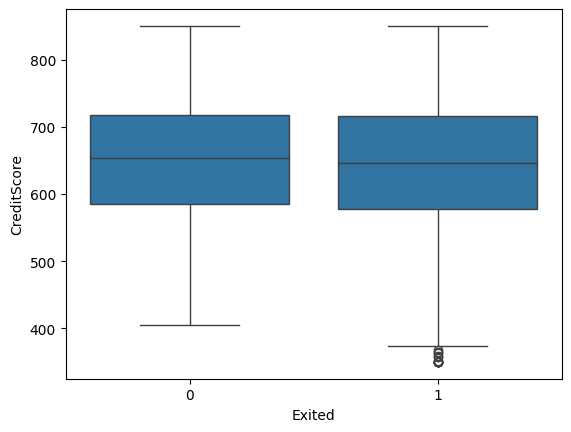

In [200]:
sns.boxplot(x='Exited', y='CreditScore', data=df)

,proportion
IsActiveMember,
1,51.51
0,48.49


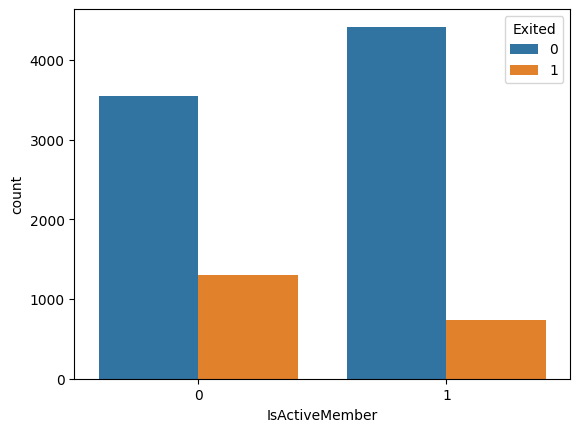

In [291]:
sns.countplot(
    x='IsActiveMember',
    hue='Exited',
    data=df
)
df['IsActiveMember'].value_counts(normalize=True)*100

<Axes: >

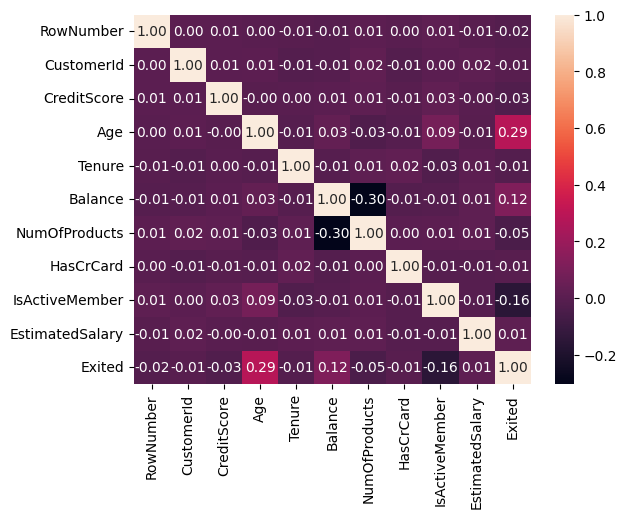

In [202]:
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f')

### Key EDA Insights

*   **Age Profile:** Older customers (median age ~45) show a significantly higher churn rate compared to younger customers (median age ~35).
*   **Geography:** Germany exhibits the highest churn proportion relative to its customer base compared to France and Spain.
*   **Activity:** Active members are much more likely to stay, highlighting the importance of customer engagement.
*   **Gender:** Female customers have a higher churn rate (approx. 25%) than male customers (approx. 16%).
*   **Balance:** A higher account balance surprisingly correlates with a higher likelihood of exiting.

In [203]:
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)

In [204]:
df.columns

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited'],
      dtype='object')

In [205]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [206]:
df["Agegroup"] = pd.cut(df["Age"], bins=[10,30,40,50,60,100],
                        labels=["10-30", "30-40", "40-50", "50-60", "60+"])

In [207]:
df["BalanceSalaryRatio"] = (df["Balance"]/(df["EstimatedSalary"] + 1))

In [208]:
df["ProductsPerTenure"] = (df["NumOfProducts"] / (df["Tenure"] + 1))

In [209]:
df_encode = pd.get_dummies(df, drop_first=True)

In [210]:
df_encode

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BalanceSalaryRatio,ProductsPerTenure,Geography_Germany,Geography_Spain,Gender_Male,Agegroup_30-40,Agegroup_40-50,Agegroup_50-60,Agegroup_60+
0,619,42,2,0.00,1,1,1,101348.88,1,0.000000,0.333333,False,False,False,False,True,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,0.744670,0.500000,False,True,False,False,True,False,False
2,502,42,8,159660.80,3,1,0,113931.57,1,1.401362,0.333333,False,False,False,False,True,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,0.000000,1.000000,False,False,False,True,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,1.587035,0.333333,False,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,0.000000,0.333333,False,False,True,True,False,False,False
9996,516,35,10,57369.61,1,1,1,101699.77,0,0.564102,0.090909,False,False,True,True,False,False,False
9997,709,36,7,0.00,1,0,1,42085.58,1,0.000000,0.125000,False,False,False,True,False,False,False
9998,772,42,3,75075.31,2,1,0,92888.52,1,0.808222,0.500000,True,False,True,False,True,False,False


### Data Preprocessing
Converting categorical variables to numerical formats and scale numerical features to ensure the models perform optimally.

In [211]:
df_encode

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BalanceSalaryRatio,ProductsPerTenure,Geography_Germany,Geography_Spain,Gender_Male,Agegroup_30-40,Agegroup_40-50,Agegroup_50-60,Agegroup_60+
0,619,42,2,0.00,1,1,1,101348.88,1,0.000000,0.333333,False,False,False,False,True,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,0.744670,0.500000,False,True,False,False,True,False,False
2,502,42,8,159660.80,3,1,0,113931.57,1,1.401362,0.333333,False,False,False,False,True,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,0.000000,1.000000,False,False,False,True,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,1.587035,0.333333,False,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,0.000000,0.333333,False,False,True,True,False,False,False
9996,516,35,10,57369.61,1,1,1,101699.77,0,0.564102,0.090909,False,False,True,True,False,False,False
9997,709,36,7,0.00,1,0,1,42085.58,1,0.000000,0.125000,False,False,False,True,False,False,False
9998,772,42,3,75075.31,2,1,0,92888.52,1,0.808222,0.500000,True,False,True,False,True,False,False


In [212]:
from sklearn.preprocessing import StandardScaler

num_cols = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary', 'Tenure']

scaler = StandardScaler()
df_encode[num_cols] = scaler.fit_transform(df_encode[num_cols])

df_encode.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BalanceSalaryRatio,ProductsPerTenure,Geography_Germany,Geography_Spain,Gender_Male,Agegroup_30-40,Agegroup_40-50,Agegroup_50-60,Agegroup_60+
0,-0.326221,0.293517,-1.041760,-1.225848,1,1,1,0.021886,1,0.000000,0.333333,False,False,False,False,True,False,False
1,-0.440036,0.198164,-1.387538,0.117350,1,0,1,0.216534,0,0.744670,0.500000,False,True,False,False,True,False,False
2,-1.536794,0.293517,1.032908,1.333053,3,1,0,0.240687,1,1.401362,0.333333,False,False,False,False,True,False,False
3,0.501521,0.007457,-1.387538,-1.225848,2,0,0,-0.108918,0,0.000000,1.000000,False,False,False,True,False,False,False
4,2.063884,0.388871,-1.041760,0.785728,1,1,1,-0.365276,0,1.587035,0.333333,False,True,False,False,True,False,False


In [213]:
X = df_encode.drop('Exited', axis=1)
y = df_encode['Exited']

In [214]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Logistic Regression

In [215]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [216]:
y_pred_lr= model.predict(X_test)

In [217]:
y_pred_lr

array([0, 0, 0, ..., 0, 0, 0])

In [218]:
y_test

,Exited
6252,0
4684,0
1731,0
4742,0
4521,0
...,...
6412,1
8285,0
7853,1
1095,1


In [219]:
accuracy_score(y_test, y_pred_lr)

0.8365

In [220]:
confusion_matrix(y_test, y_pred_lr)

array([[1550,   57],
       [ 270,  123]])

In [221]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.85      0.96      0.90      1607
           1       0.68      0.31      0.43       393

    accuracy                           0.84      2000
   macro avg       0.77      0.64      0.67      2000
weighted avg       0.82      0.84      0.81      2000



# KNN

In [271]:
from sklearn.neighbors import KNeighborsClassifier

In [272]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [223]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [224]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [225]:
y_pred_knn = knn.predict(X_test_scaled)

In [226]:
accuracy_score(y_test, y_pred_knn)

0.8295

In [227]:
confusion_matrix(y_test, y_pred_knn)

array([[1511,   96],
       [ 245,  148]])

In [228]:
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.86      0.94      0.90      1607
           1       0.61      0.38      0.46       393

    accuracy                           0.83      2000
   macro avg       0.73      0.66      0.68      2000
weighted avg       0.81      0.83      0.81      2000



# Naive Bayes

In [229]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)

GaussianNB()

In [230]:
y_pred_nb = nb.predict(X_test)

In [231]:
accuracy_score(y_test, y_pred_nb)

0.822

In [232]:
confusion_matrix(y_test, y_pred_nb)

array([[1479,  128],
       [ 228,  165]])

In [233]:
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

           0       0.87      0.92      0.89      1607
           1       0.56      0.42      0.48       393

    accuracy                           0.82      2000
   macro avg       0.71      0.67      0.69      2000
weighted avg       0.81      0.82      0.81      2000



# Decision Tree

In [234]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_scaled, y_train)

DecisionTreeClassifier(random_state=42)

In [235]:
y_pred_dt = dt.predict(X_test_scaled)

In [236]:
accuracy_score(y_test, y_pred_dt)

0.595

In [237]:
confusion_matrix(y_test, y_pred_dt)

array([[959, 648],
       [162, 231]])

In [238]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.86      0.60      0.70      1607
           1       0.26      0.59      0.36       393

    accuracy                           0.59      2000
   macro avg       0.56      0.59      0.53      2000
weighted avg       0.74      0.59      0.64      2000



# SVM

In [239]:
from sklearn.svm import SVC

svm = SVC(kernel = 'rbf')
svm.fit(X_train_scaled, y_train)

SVC()

In [240]:
y_pred_svc = svm.predict(X_test_scaled)

In [241]:
accuracy_score(y_test, y_pred_svc)

0.8625

In [242]:
confusion_matrix(y_test, y_pred_svc)

array([[1559,   48],
       [ 227,  166]])

In [243]:
print(classification_report(y_test, y_pred_svc))

              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1607
           1       0.78      0.42      0.55       393

    accuracy                           0.86      2000
   macro avg       0.82      0.70      0.73      2000
weighted avg       0.85      0.86      0.85      2000



## Model Comparison

In [244]:
from sklearn.metrics import precision_score, recall_score

# Summarize all model performances
models = {
    'Logistic Regression': y_pred_lr,
    'KNN': y_pred_knn,
    'Naive Bayes': y_pred_nb,
    'Decision Tree': y_pred_dt,
    'SVM': y_pred_svc
}

results = []
for name, pred in models.items():
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1 Score': f1_score(y_test, pred)
    })

comparison_df = pd.DataFrame(results).sort_values(by='F1 Score', ascending=False)
display(comparison_df)

,Model,Accuracy,Precision,Recall,F1 Score
4,SVM,0.8625,0.775701,0.422392,0.546952
2,Naive Bayes,0.8220,0.563140,0.419847,0.481050
1,KNN,0.8295,0.606557,0.376590,0.464678
0,Logistic Regression,0.8365,0.683333,0.312977,0.429319
3,Decision Tree,0.5950,0.262799,0.587786,0.363208


# K-Fold Cross-Validation

In [275]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

In [247]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [248]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [249]:
scores = cross_val_score(svm, X_scaled, y, cv=5, scoring='recall')
print(scores)
print(scores.mean())

[0.39215686 0.45098039 0.42506143 0.46437346 0.39312039]
0.4251385074914487


### Hyperparameter Tuning


In [250]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10],
    'gamma': [1, 0.1, 0.01],
    'kernel': ['rbf']
}

grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=1, cv=5, scoring='f1')

grid.fit(X_train_scaled, y_train)

print(f"Best Parameters: {grid.best_params_}")
print(f"Best F1 Score: {grid.best_score_:.4f}")

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best Parameters: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Best F1 Score: 0.5438


In [251]:
grid_predictions = grid.predict(X_test_scaled)
print(classification_report(y_test, grid_predictions))


              precision    recall  f1-score   support

           0       0.88      0.94      0.91      1607
           1       0.67      0.46      0.55       393

    accuracy                           0.85      2000
   macro avg       0.77      0.70      0.73      2000
weighted avg       0.84      0.85      0.84      2000



### Testing the Final Model on New Customer Data


In [274]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# New Customer Profiles
new_customers_raw = pd.DataFrame([
    {'CreditScore': 650, 'Geography': 'France', 'Gender': 'Female', 'Age': 65, 'Tenure': 2, 'Balance': 150000, 'NumOfProducts': 3, 'HasCrCard': 1, 'IsActiveMember': 0, 'EstimatedSalary': 100000},
    {'CreditScore': 800, 'Geography': 'Spain', 'Gender': 'Male', 'Age': 25, 'Tenure': 8, 'Balance': 0, 'NumOfProducts': 2, 'HasCrCard': 1, 'IsActiveMember': 1, 'EstimatedSalary': 50000},
    {'CreditScore': 500, 'Geography': 'Germany', 'Gender': 'Female', 'Age': 52, 'Tenure': 1, 'Balance': 120000, 'NumOfProducts': 1, 'HasCrCard': 0, 'IsActiveMember': 0, 'EstimatedSalary': 180000},
    {'CreditScore': 720, 'Geography': 'France', 'Gender': 'Male', 'Age': 40, 'Tenure': 5, 'Balance': 80000, 'NumOfProducts': 1, 'HasCrCard': 1, 'IsActiveMember': 1, 'EstimatedSalary': 90000},
    {'CreditScore': 450, 'Geography': 'Germany', 'Gender': 'Female', 'Age': 38, 'Tenure': 3, 'Balance': 200000, 'NumOfProducts': 4, 'HasCrCard': 1, 'IsActiveMember': 0, 'EstimatedSalary': 150000},
    {'CreditScore': 600, 'Geography': 'Spain', 'Gender': 'Female', 'Age': 31, 'Tenure': 9, 'Balance': 0, 'NumOfProducts': 2, 'HasCrCard': 1, 'IsActiveMember': 1, 'EstimatedSalary': 120000},
    {'CreditScore': 850, 'Geography': 'France', 'Gender': 'Male', 'Age': 70, 'Tenure': 10, 'Balance': 0, 'NumOfProducts': 1, 'HasCrCard': 1, 'IsActiveMember': 1, 'EstimatedSalary': 20000},
    {'CreditScore': 580, 'Geography': 'Germany', 'Gender': 'Male', 'Age': 45, 'Tenure': 2, 'Balance': 135000, 'NumOfProducts': 1, 'HasCrCard': 0, 'IsActiveMember': 1, 'EstimatedSalary': 160000},
    {'CreditScore': 710, 'Geography': 'Spain', 'Gender': 'Female', 'Age': 48, 'Tenure': 4, 'Balance': 95000, 'NumOfProducts': 2, 'HasCrCard': 1, 'IsActiveMember': 0, 'EstimatedSalary': 85000},
    {'CreditScore': 620, 'Geography': 'France', 'Gender': 'Male', 'Age': 34, 'Tenure': 7, 'Balance': 110000, 'NumOfProducts': 2, 'HasCrCard': 0, 'IsActiveMember': 1, 'EstimatedSalary': 75000}
])

# Preprocessing & Alignment Pipeline
def preprocess_new_data(input_df, reference_columns, scaler_training_df):
    df_proc = input_df.copy()
    df_proc['Agegroup'] = pd.cut(df_proc['Age'], bins=[10,30,40,50,60,100], labels=['10-30', '30-40', '40-50', '50-60', '60+'])
    df_proc['BalanceSalaryRatio'] = (df_proc['Balance'] / (df_proc['EstimatedSalary'] + 1))
    df_proc['ProductsPerTenure'] = (df_proc['NumOfProducts'] / (df_proc['Tenure'] + 1))

    # One-hot encoding
    df_enc = pd.get_dummies(df_proc, drop_first=True)

    # Align columns with X.columns
    for col in reference_columns:
        if col not in df_enc.columns:
            df_enc[col] = 0

    # Ensure exact order as reference_columns to avoid ValueError
    df_enc = df_enc[list(reference_columns)]

    scaler = StandardScaler()
    scaler.fit(scaler_training_df)
    return scaler.transform(df_enc)

# Re-construct training reference for consistent scaling
X_ref_raw = df.copy()
X_ref_raw['Agegroup'] = pd.cut(df['Age'], bins=[10,30,40,50,60,100], labels=['10-30', '30-40', '40-50', '50-60', '60+'])
X_ref_raw['BalanceSalaryRatio'] = (df['Balance'] / (df['EstimatedSalary'] + 1))
X_ref_raw['ProductsPerTenure'] = (df['NumOfProducts'] / (df['Tenure'] + 1))
X_ref = pd.get_dummies(X_ref_raw, drop_first=True)[list(X.columns)]

new_data_final = preprocess_new_data(new_customers_raw, X.columns, X_ref)

# Prediction
results_df = new_customers_raw.copy()
results_df['Prediction'] = ['Churn' if p == 1 else 'No Churn' for p in grid.predict(new_data_final)]
results_df['Confidence'] = grid.decision_function(new_data_final).round(2)

display(results_df[['Age', 'Geography', 'IsActiveMember', 'Balance', 'Prediction', 'Confidence']])

,Age,Geography,IsActiveMember,Balance,Prediction,Confidence
0,65,France,0,150000,Churn,1.10
1,25,Spain,1,0,No Churn,-1.81
2,52,Germany,0,120000,Churn,1.08
3,40,France,1,80000,No Churn,-1.16
4,38,Germany,0,200000,Churn,1.77
5,31,Spain,1,0,No Churn,-1.09
6,70,France,1,0,No Churn,-1.17
7,45,Germany,1,135000,No Churn,-0.35
8,48,Spain,0,95000,No Churn,-0.74
9,34,France,1,110000,No Churn,-1.62


### Conclusion

**1. Best Model**
* The **Tuned SVM** is the most reliable model, effectively balancing the detection of churners with overall accuracy.

**2. Likely to leave**
*   **Older Customers (45+):** They have a significantly higher exit rate.
*   **Customers in Germany:** Churn is higher here than in France or Spain.
*   **Inactive Members:** Engagement is the biggest shield against churn.

**3. Bank need to do**
*   **Targeted Loyalty Programs:** Create specific offers for the 45-60 age demographic in Germany.
*   **Re-engagement Campaigns:** Reach out to 'Inactive' members with personalized emails or app notifications to bring them back to the platform.
*   **Early Warning System:** Use this model to flag high-risk customers automatically so the support team can intervene before they decide to close their accounts.
